In [1]:
# Цей набір даних включає A/B-тестування маркетингової кампанії, для того щоб перевірити чи впливає реклама на кількість покупок
#  Якщо «ad», то людина бачила рекламу, якщо «psa», то вона бачила лише соціальну рекламу

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [3]:
data = pd.read_csv(r'C:\Users\PC\Desktop\data\marketing_AB.csv')
data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
data = data.drop(columns = 'Unnamed: 0')

In [7]:
# Роблю вибірку груп однакового розміру

group_ad = df[df['test group'] == 'ad'].sample (n = 5000, random_state = 42)
group_psa = df[df['test group'] == 'psa'].sample (n = 5000, random_state = 42)
df = pd.concat([group_ad, group_psa])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,921784,psa,False,12,Wednesday,13
1,1361759,ad,False,1,Monday,22
2,1571167,ad,False,22,Saturday,19
3,1476602,ad,False,65,Monday,14
4,1289478,ad,False,22,Thursday,18


In [8]:
## Гіпотези
# Нульова: Рівні конверсії між групами 'ad' та 'psa'
# Альтернативна: Нерівні конверсії між групами

df.groupby('test group')['converted'].mean()

test group
ad     0.0264
psa    0.0202
Name: converted, dtype: float64

In [9]:
# Візуалізую конверсію

import seaborn as sns

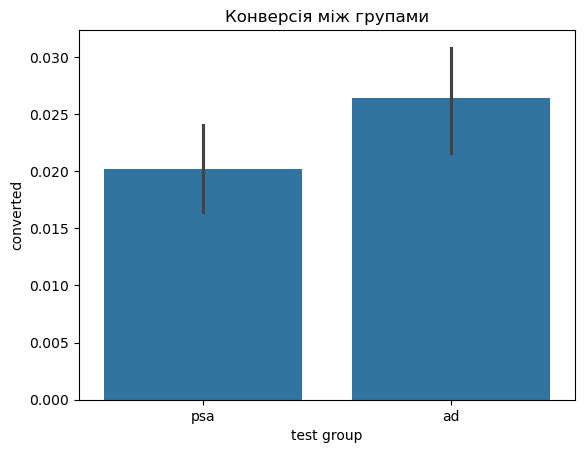

In [11]:
sns.barplot(data=df, x='test group', y='converted')
plt.title("Конверсія між групами")
plt.show()

In [13]:
# Z-test, чи різниця між групами статистично значуща

convert_ad = df[df['test group']=='ad']['converted']
convert_psa = df[df['test group']=='psa']['converted']

count = np.array([convert_ad.sum(), convert_psa.sum()])
nobs = np.array([convert_ad.count(), convert_psa.count()])

stat, pval = proportions_ztest(count, nobs)
pval

np.float64(0.0398829749880044)

In [14]:
stat

np.float64(2.0549588963389955)

In [15]:
## Висновок
#За результатами аналізу Конверсія груп відрізняється: 26.4% для ad та 20.2% для psa. 
#Статистичний тест показав p-value = 0.039, що менше за поріг 0.05, тому нульову гіпотезу можна відхилити. 
#Різниця між групами є статистично значуща. Цей приріст не є випадковим коливанням даних, і реклама ad приносить більше покупок ніж psa.

In [16]:
# Рахую кількість проглянутих реклам за групами

count_views = df.groupby('test group')['total ads'].agg(['mean', 'median', 'std'])
count_views

,mean,median,std
test group,,,
ad,25.0380,13.0,41.996549
psa,24.2854,12.0,41.615443


In [17]:
# Висновок
# Аналіз показів реклам показав, що обидві групи мали однакову середню кількість контактів (ad ~25%, psa ~24%). 
# Це виключає ймовірність того що вища конверсія в групі ad спричинена лише більшою кількістю переглядів.

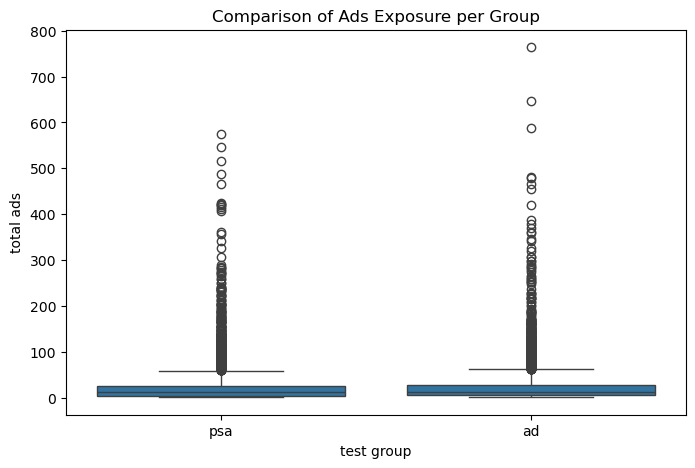

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='test group', y='total ads', data=df)
plt.title('Comparison of Ads Exposure per Group')
plt.show()

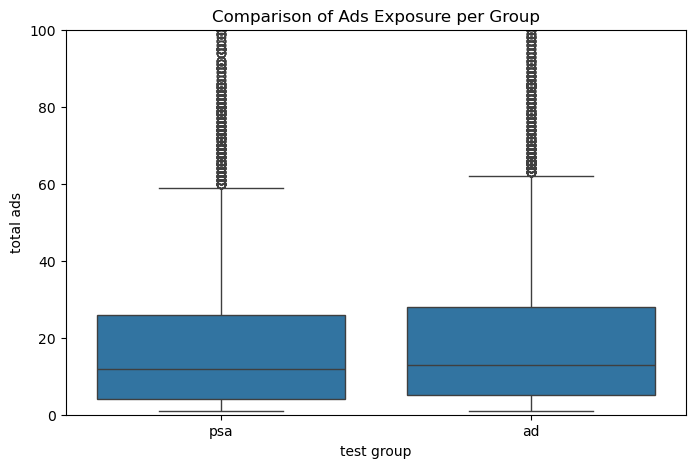

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='test group', y='total ads', data=df)
plt.title('Comparison of Ads Exposure per Group')
plt.ylim(0,100)
plt.show()

In [21]:
# Висновок
# Медіанна - 13 суттєво нижча за середню (25), що пояснюється наявністю великої кількості користувачів, які бачили рекламу понад 100 разів

In [ ]:
## Аналіз розподілу показав що обидві групи були піддані впливу реклами з майже однаковою інтенсивністю.
## Це підтверджує, що тест був справедливим і результати не були спотворені тим, що одна група бачила більше реклами ніж інша.